In [4]:
table_name = "const_vdv_pretty_with_mw_volume.tsv"
import pandas as pd
df = pd.read_csv(table_name, sep="\t")
df.head(1)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume
0,Азот,N2,0.137,38.7,28.014,2.998428


In [6]:
%pip install scikit-learn

In [5]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()

In [6]:
reg.fit(df[["Volume", "Const_a"]], df["Mol_weight"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
df["Mol_weight_pred"] = (
    df.Volume * reg.coef_[0] 
    + df.Const_a * reg.coef_[1] 
    + reg.intercept_
)

$$ y_i = k_1 x_{1, i} + k_2 x_{2, i} + m $$

In [8]:
reg.intercept_

np.float64(1.0799074733642584)

In [9]:
df["Mol_weight_pred"] = \
    df[["Volume", "Const_a"]].apply(
        lambda row: sum(row * reg.coef_) +  reg.intercept_,
        axis=1
    )

In [10]:
df.head(1)

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,Mol_weight_pred
0,Азот,N2,0.137,38.7,28.014,2.998428,33.537015


<Axes: xlabel='Volume', ylabel='Mol_weight'>

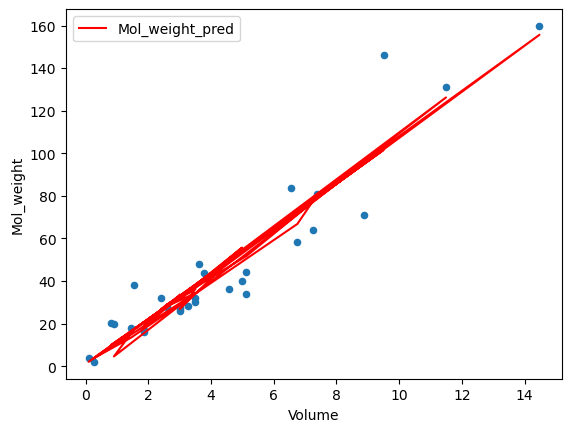

In [11]:
import matplotlib.pyplot as plt
_, ax = plt.subplots()
df.plot(x="Volume", y="Mol_weight", kind="scatter", ax=ax)
df.plot(x="Volume", y="Mol_weight_pred", color="red", ax=ax)

<Axes: xlabel='Volume', ylabel='Mol_weight'>

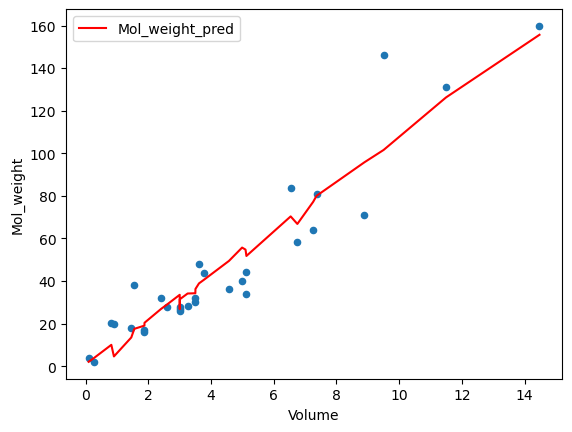

In [12]:
df_sv = df.sort_values(by="Volume")
_, ax = plt.subplots()
df_sv.plot(x="Volume", y="Mol_weight", kind="scatter", ax=ax)
df_sv.plot(x="Volume", y="Mol_weight_pred", color="red", ax=ax)

In [13]:
from sklearn.metrics import r2_score

In [14]:
r2_score(df["Mol_weight"], df["Mol_weight_pred"])

0.8859390731580069

In [15]:
reg.score(df[["Volume", "Const_a"]], df["Mol_weight"])

0.8859390731580069

In [16]:
reg = LinearRegression()
reg.fit(df[["Volume"]], df["Mol_weight"])
reg.score(df[["Volume"]], df["Mol_weight"])

0.8829642018987853

In [17]:
df.head()

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,Mol_weight_pred
0,Азот,N2,0.1370,38.7,28.014,2.998428,33.537015
1,Аммиак,NH3,0.4225,37.1,17.031,1.873579,19.067048
2,Аргон,Ar,0.1355,32.0,39.900,4.988916,55.712902
3,Ацетилен,C2H2,0.4516,52.2,26.040,3.001687,31.431302
4,Бром,Br2,0.9750,59.1,159.810,14.476459,155.648405


In [18]:
df["Mol_weight_delta"] = df["Mol_weight"] - df["Mol_weight_pred"]

<Axes: ylabel='Frequency'>

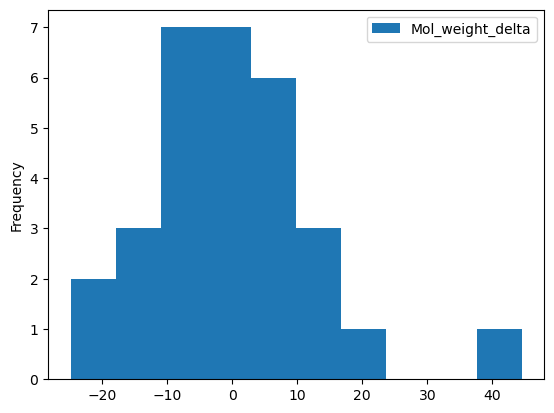

In [19]:
df.plot(y="Mol_weight_delta", kind="hist")

In [21]:
df[df["Mol_weight_delta"].abs() > df["Mol_weight_delta"].std()]

,Substance,Formula,Const_a,Const_b,Mol_weight,Volume,Mol_weight_pred,Mol_weight_delta
2,Аргон,Ar,0.1355,32.0,39.900000,4.988916,55.712902,-15.812902
9,Гексафторид серы,SF6,0.7857,87.9,146.060000,9.503456,101.558922,44.501078
13,Криптон,Kr,0.5193,10.6,83.800000,6.538266,70.352987,13.447013
21,Сероводород,H2S,0.4544,43.4,34.080000,5.098625,54.763315,-20.683315
23,Фтор,F2,0.1171,29.0,37.996806,1.551469,17.559464,20.437343
24,Фтороводород,HF,0.9565,73.9,20.006400,0.900523,4.595471,15.410929
25,Хлор,Cl2,0.6343,54.2,70.900000,8.890355,95.762387,-24.862387


In [22]:
%pip install mendeleev

In [25]:
import mendeleev
eF = mendeleev.element("F")
eF.atomic_volume

12233.35683386993

In [27]:
eF.electronegativity()

3.98

In [28]:
import json
import requests

radii = json.loads(requests.get(
    "https://cdn.lazarev.fun/data/radii.json"
).text.replace("'", '"'))

In [52]:
from math import pi
volumes = pd.concat(
    [
        pd.Series(radii), 
         4 / 3 * pi * pd.Series(radii)**3
    ], 
    axis=1
)
volumes.rename(columns={0: "r", 1: "v"}, inplace=True)
volumes["v_true"] = volumes.index.map(
    lambda e: mendeleev.element(e).atomic_volume
)
volumes.head(5)

,r,v,v_true
H,0.31,0.124788,12292.682927
He,0.28,0.091952,24406.109756
Li,1.28,8.784530,12.996255
Be,0.96,3.705973,4.871450
B,0.84,2.482713,4.619658


In [54]:
reg = LinearRegression()
reg.fit(volumes[["v"]], volumes["v_true"])
reg.score(volumes[["v"]], volumes["v_true"])

0.11457861090859012

In [55]:
volumes["v_pred"] = reg.predict(volumes[["v"]])

<Axes: xlabel='v', ylabel='v_pred'>

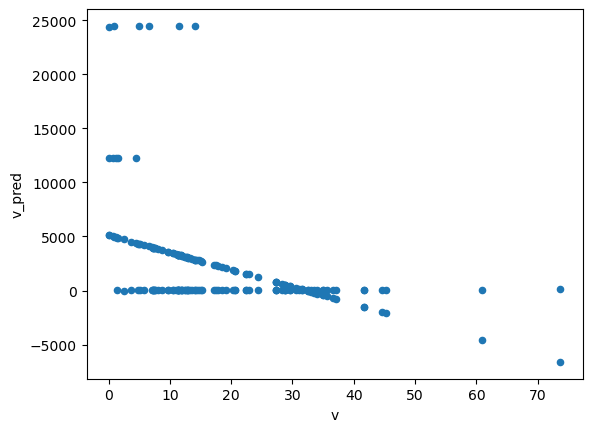

In [56]:
_, ax = plt.subplots()
volumes.plot(x="v", y="v_true", kind="scatter", ax=ax)
volumes.plot(x="v", y="v_pred", kind="scatter", ax=ax)